In [1]:
from jax import random, jit, numpy as jnp
from jax.scipy import linalg
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider
from lqg.tracking.delay import TemporalDelayModel
from lqg.tracking.subjective import SubjectiveActor
from lqg import xcorr, LQG, System
from lqg.utils import time_stack_spec

In [2]:
dt = 1 / 18.18

random_walk_std = 1.
action_variability = 0.5
action_cost = 0.1


## Multisensory system

We now set up the system with delays. To do this, we augment the state of the system with the $k$ most recent time steps (if our maximal delay is $k$ time steps). This involves a change in the matrices $A$, $B$, $V$, and $Q$, such that we retain the original dynamics, but simply keep track of the state at the $k$ previous time steps. The observation matrix $F$ then picks out the observation at the appropriate delay. We can turn this into a multisensory observation by stacking up multiple observation matrices $F$ (vertically) and multiple observation noise matrices $W$ (block-diagonally). This approach is common in linear control models of reaching tasks with delays (e.g. Izawa & Shadmehr, 2008; Crevecoeur et al., 2016).

In [3]:
from cppp.models.multisensory import multisensory_delay_system, MultisensoryDelayModel, UnisensoryDelayModel

## Simulation

We define one observation noise level for the visual input and one for the proprioceptive input. We also define different delays for the two sensory modalities. Here, I am assuming 0 time steps (0ms) delay for proprioception and 3 time steps (~165 ms) delay for vision, but we can change these values and see their effect on the CCGs.

In [4]:
sigma_proprioceptive = 10.
sigma_visual = 20.

delay_proprioceptive = 1
delay_visual = 2



multisensory
visual
proprioceptive


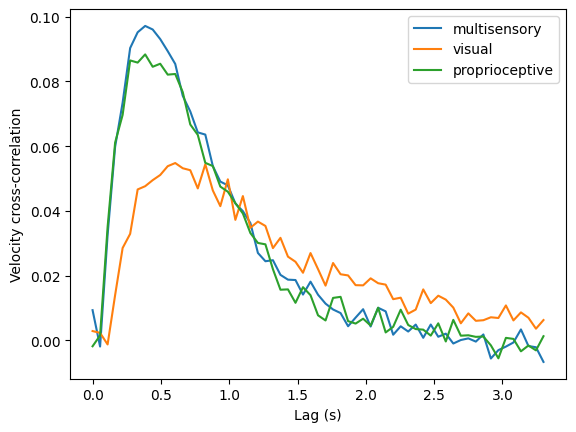

In [5]:

models = {
        "multisensory": MultisensoryDelayModel(delays=[delay_proprioceptive, delay_visual], sigmas=[sigma_proprioceptive, sigma_visual]),
        "visual": UnisensoryDelayModel(delay=delay_visual, sigma=sigma_visual),
        "proprioceptive": UnisensoryDelayModel(delay=delay_proprioceptive, sigma=sigma_proprioceptive),
    }

key = random.PRNGKey(12398)

for name, model in models.items():
    print(name)
    key, subkey = random.split(key)
    x = model.simulate(rng_key=subkey, n=100)
    vels = jnp.diff(x, axis=-2)

    lags, correls = xcorr(vels[..., 1], vels[..., 0], maxlags=60)

    plt.plot(lags[60:] * dt, correls.mean(axis=0)[60:], label=name)

plt.xlabel("Lag (s)")
plt.ylabel("Velocity cross-correlation")
plt.legend()
plt.show()

## Bias

In [11]:
dt = 1 / 18.18

random_walk_std = 1.0
action_variability = 0.5
action_cost = 0.1


from cppp.models.multisensory import BiasMultisensoryDelayModel, SubjectiveBiasMultisensoryDelayModel


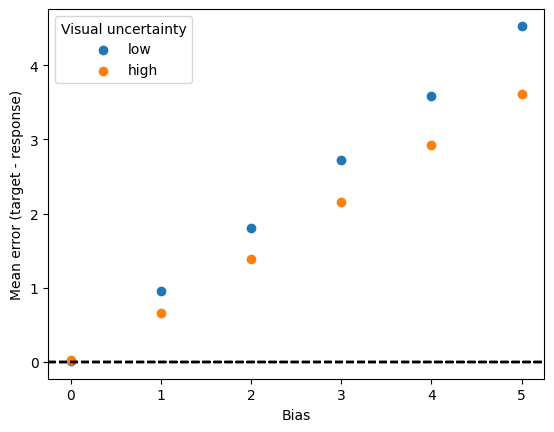

In [13]:
perceptual_uncertainty = {"low": 2.5, "high": 5.5}

key = random.PRNGKey(12398)
for i, (level, sigma) in enumerate(perceptual_uncertainty.items()):
    # dynamics = multisensory_delay_system(A, B, V, Fs, [W_proprioceptive, sigma * W_visual], Q, R, delays=[delay_proprioceptive, delay_visual], T=1000)
    # actor = multisensory_delay_system(A_subj, B_subj, V_subj, Fs_subj, [W_proprioceptive, sigma * W_visual], Q_subj, R_subj, delays=[delay_proprioceptive, delay_visual], T=1000)

    model = SubjectiveBiasMultisensoryDelayModel(
        process_noise=random_walk_std,
        sigmas=[sigma_proprioceptive, sigma],
        action_variability=action_variability,
        action_cost=action_cost,
        dt=dt,
        delays=[delay_proprioceptive, delay_visual],
        T=1000,
    )

    for bias in [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]:
        key, subkey = random.split(key)
        x = model.simulate(
            rng_key=subkey, n=100, x0=jnp.array([0.0, 0.0, bias] + [0.0] * 6)
        )
        error = jnp.mean((x[..., 1] - x[..., 0]))

        plt.scatter(bias, error, color=f"C{i}", label=level if bias == 0.0 else "")
        plt.axhline(0, color="black", linestyle="--")
        plt.xlabel("Bias")
        plt.ylabel("Mean error (target - response)")
plt.legend(title="Visual uncertainty")
plt.show()

In [ ]:
x